In [2]:
import pandas as pd


In [5]:
df = pd.read_csv('../data/search key/raw/predicted_search_key_combined_cleaned.csv')
df.head()

,search key,type,source,cluster_id,variants,predicted_relevance
0,lung transplant rejection,['lung transplant'],google_complete,0,"['lung transplant rejection after 5 years', 'l...",1
1,lung transplant history,['lung transplant'],google_complete,1,"['lung transplant last', 'lung transplant time...",1
2,heart transplant rejection,['heart transplant'],google_complete,2,"['heart transplant rejection stages', 'heart t...",1
3,kidney transplant hospitals in florida,['kidney transplant'],google_complete,3,['kidney transplant tampa general hospital'],1
4,heart lung transplant uk,['heart-lung transplant'],google_complete,4,"['first heart lung transplant uk', 'heart and ...",1


In [8]:
df.groupby("type").predicted_relevance.value_counts()

type                       predicted_relevance
['heart transplant']       1                      195
                           0                       68
['heart-lung transplant']  1                       59
                           0                        6
['kidney transplant']      1                      265
                           0                       33
['liver transplant']       1                      222
                           0                       40
['lung transplant']        1                      223
                           0                       18
['pancreas transplant']    1                       94
                           0                       16
Name: count, dtype: int64

Text(0.5, 0, 'Type')

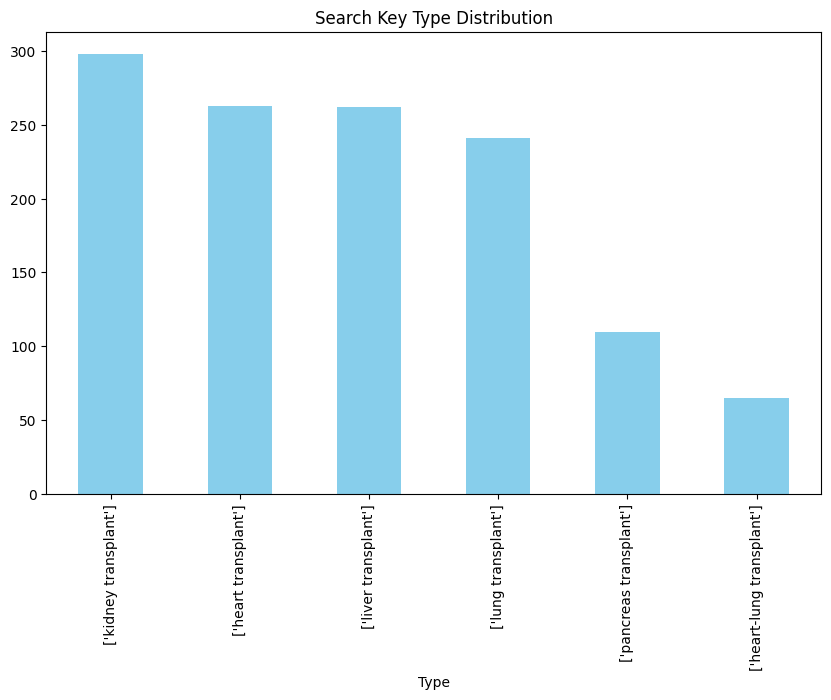

In [9]:
import matplotlib.pyplot as plt

# 计算每个类型的搜索键数量
type_counts = df['type'].value_counts()

# 绘制柱状图
plt.figure(figsize=(10, 6))
type_counts.plot(kind='bar', color='skyblue')


plt.title('Search Key Type Distribution')
plt.xlabel('Type')

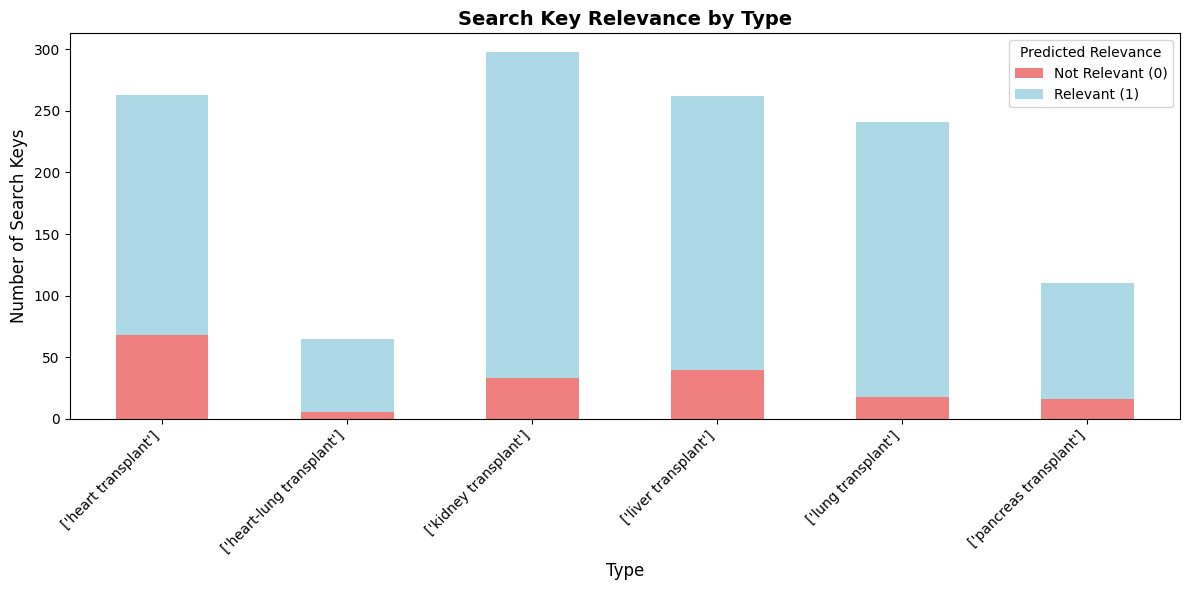

Relevance Statistics by Type:
predicted_relevance         0    1
type                              
['heart transplant']       68  195
['heart-lung transplant']   6   59
['kidney transplant']      33  265
['liver transplant']       40  222
['lung transplant']        18  223
['pancreas transplant']    16   94

Total relevant: 1058
Total not relevant: 181
Overall relevance rate: 85.39%


In [13]:
# 根据predicted_relevance的值，呈现不同的颜色
# 创建分组柱状图，显示每个类型的相关和不相关搜索键数量

# 计算每个类型的相关和不相关数量
relevance_by_type = df.groupby(['type', 'predicted_relevance']).size().unstack(fill_value=0)

# 设置颜色
colors = {0: 'lightcoral', 1: 'lightblue'}

# 创建柱状图
fig, ax = plt.subplots(figsize=(12, 6))

# 绘制堆叠柱状图
relevance_by_type.plot(kind='bar', stacked=True, 
                      color=[colors[0], colors[1]], 
                      ax=ax)

plt.title('Search Key Relevance by Type', fontsize=14, fontweight='bold')
plt.xlabel('Type', fontsize=12)
plt.ylabel('Number of Search Keys', fontsize=12)
plt.legend(['Not Relevant (0)', 'Relevant (1)'], title='Predicted Relevance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 打印统计信息
print("Relevance Statistics by Type:")
print(relevance_by_type)
print(f"\nTotal relevant: {relevance_by_type[1].sum()}")
print(f"Total not relevant: {relevance_by_type[0].sum()}")
print(f"Overall relevance rate: {relevance_by_type[1].sum() / (relevance_by_type[0].sum() + relevance_by_type[1].sum()):.2%}")



In [16]:
df[df.predicted_relevance == 0].[['type', 'search_key']].to_csv('../data/search key/raw/not_relevant_search_keys.csv', index=False)

SyntaxError: invalid syntax (1098065423.py, line 1)

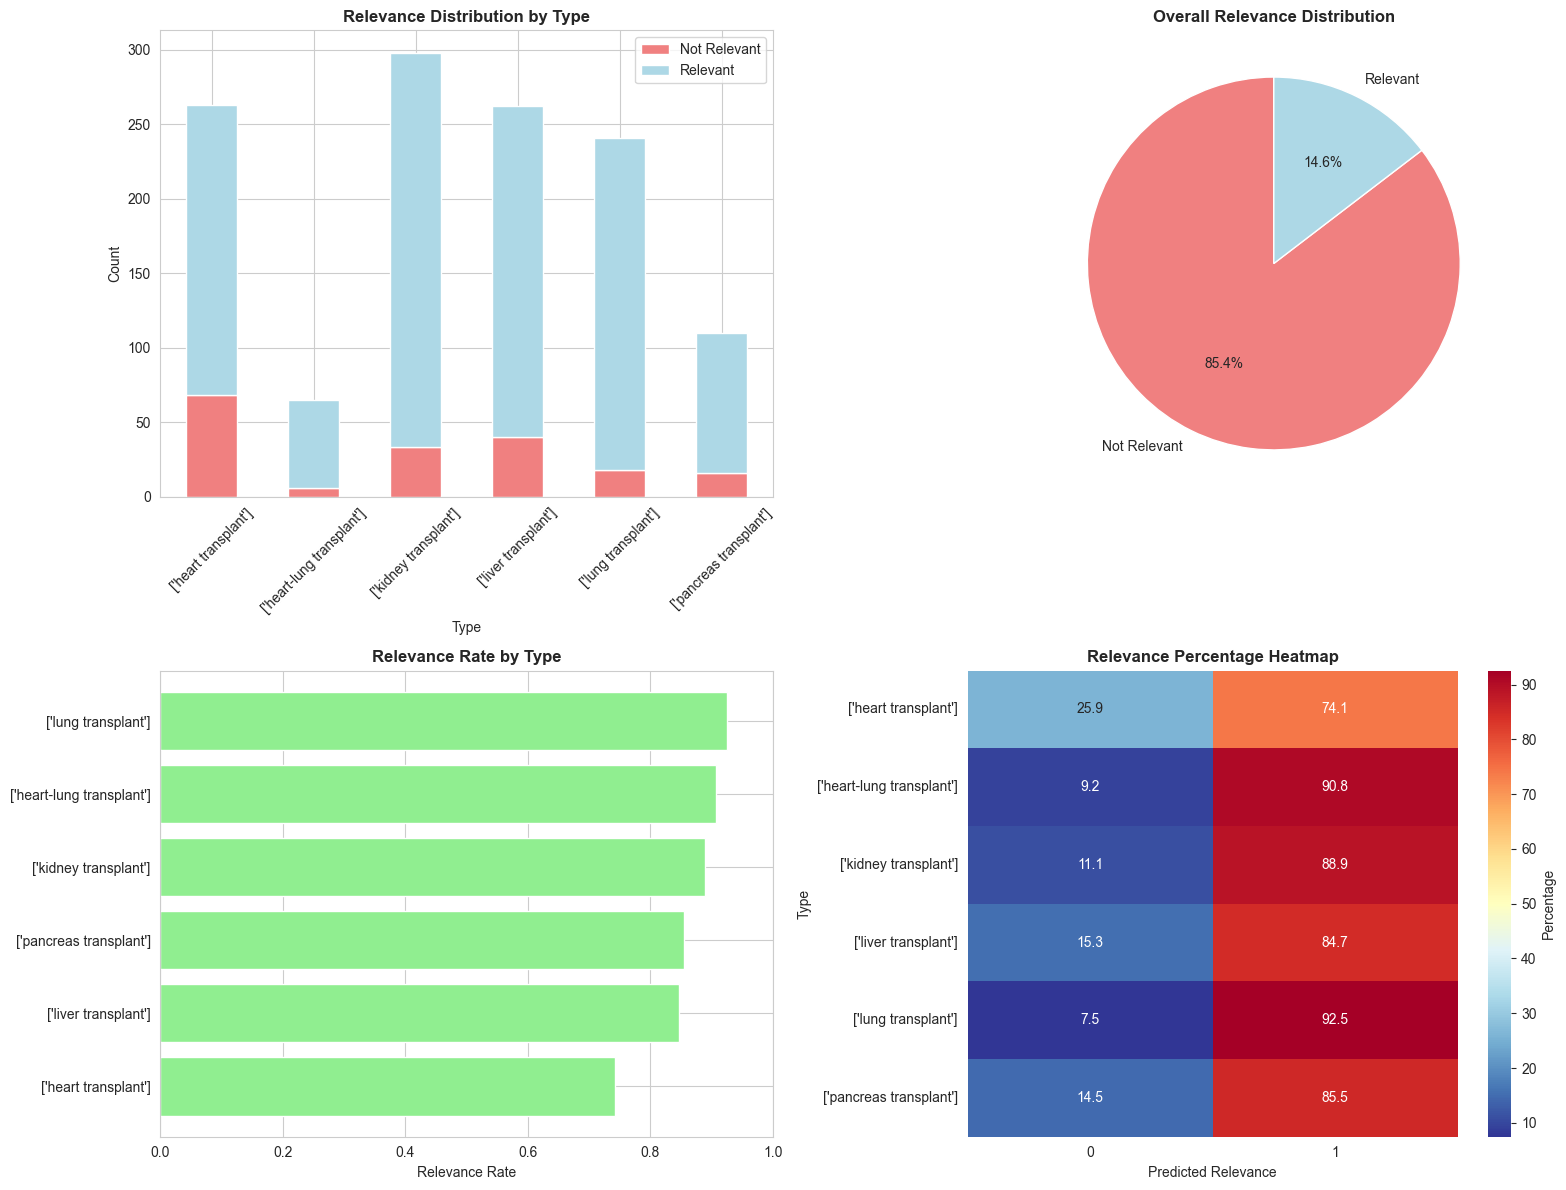

DETAILED RELEVANCE ANALYSIS
Total search keys: 1239
Relevant keys: 1058
Not relevant keys: 181
Overall relevance rate: 85.39%

Relevance by Type:
  ['lung transplant']: 223/241 (92.5%)
  ['heart transplant']: 195/263 (74.1%)
  ['kidney transplant']: 265/298 (88.9%)
  ['heart-lung transplant']: 59/65 (90.8%)
  ['pancreas transplant']: 94/110 (85.5%)
  ['liver transplant']: 222/262 (84.7%)


In [14]:
# 更详细的可视化分析
import seaborn as sns

# 设置样式
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# 创建子图
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 堆叠柱状图 - 按类型分组
relevance_by_type.plot(kind='bar', stacked=True, 
                      color=['lightcoral', 'lightblue'], 
                      ax=axes[0,0])
axes[0,0].set_title('Relevance Distribution by Type', fontweight='bold')
axes[0,0].set_xlabel('Type')
axes[0,0].set_ylabel('Count')
axes[0,0].legend(['Not Relevant', 'Relevant'])
axes[0,0].tick_params(axis='x', rotation=45)

# 2. 饼图 - 整体相关性分布
relevance_counts = df['predicted_relevance'].value_counts()
axes[0,1].pie(relevance_counts.values, 
              labels=['Not Relevant', 'Relevant'],
              colors=['lightcoral', 'lightblue'],
              autopct='%1.1f%%',
              startangle=90)
axes[0,1].set_title('Overall Relevance Distribution', fontweight='bold')

# 3. 水平柱状图 - 每个类型的相关性比例
relevance_rates = df.groupby('type')['predicted_relevance'].mean().sort_values(ascending=True)
axes[1,0].barh(range(len(relevance_rates)), relevance_rates.values, 
               color='lightgreen')
axes[1,0].set_yticks(range(len(relevance_rates)))
axes[1,0].set_yticklabels(relevance_rates.index)
axes[1,0].set_xlabel('Relevance Rate')
axes[1,0].set_title('Relevance Rate by Type', fontweight='bold')
axes[1,0].set_xlim(0, 1)

# 4. 热力图 - 相关性矩阵
# 创建相关性热力图数据
heatmap_data = df.groupby(['type', 'predicted_relevance']).size().unstack(fill_value=0)
heatmap_data_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

sns.heatmap(heatmap_data_pct, annot=True, fmt='.1f', cmap='RdYlBu_r',
            ax=axes[1,1], cbar_kws={'label': 'Percentage'})
axes[1,1].set_title('Relevance Percentage Heatmap', fontweight='bold')
axes[1,1].set_xlabel('Predicted Relevance')
axes[1,1].set_ylabel('Type')

plt.tight_layout()
plt.show()

# 详细统计报告
print("="*60)
print("DETAILED RELEVANCE ANALYSIS")
print("="*60)
print(f"Total search keys: {len(df)}")
print(f"Relevant keys: {df['predicted_relevance'].sum()}")
print(f"Not relevant keys: {(df['predicted_relevance'] == 0).sum()}")
print(f"Overall relevance rate: {df['predicted_relevance'].mean():.2%}")
print("\nRelevance by Type:")
for type_name in df['type'].unique():
    type_data = df[df['type'] == type_name]
    relevant_count = type_data['predicted_relevance'].sum()
    total_count = len(type_data)
    rate = relevant_count / total_count
    print(f"  {type_name}: {relevant_count}/{total_count} ({rate:.1%})")


In [ ]:
# 导出不相关的搜索关键词
not_relevant_df = df[df.predicted_relevance == 0][['type', 'search key']]
not_relevant_df.to_csv('../data/search key/raw/not_relevant_search_keys.csv', index=False)

print(f"导出了 {len(not_relevant_df)} 个不相关的搜索关键词")
print("文件保存到: ../data/search key/raw/not_relevant_search_keys.csv")
print("\n不相关搜索关键词预览:")
print(not_relevant_df.head(10))


In [ ]:
# 导出相关的搜索关键词
relevant_df = df[df.predicted_relevance == 1][['type', 'search key']]
relevant_df.to_csv('../data/search key/raw/relevant_search_keys.csv', index=False)

print(f"导出了 {len(relevant_df)} 个相关的搜索关键词")
print("文件保存到: ../data/search key/raw/relevant_search_keys.csv")
print("\n相关搜索关键词预览:")
print(relevant_df.head(10))


In [17]:
# 按类型分别导出相关和不相关的搜索关键词
import os

# 创建输出目录
output_dir = '../data/search key/raw/by_type'
os.makedirs(output_dir, exist_ok=True)

print("按类型分别导出搜索关键词:")
print("="*50)

for type_name in df['type'].unique():
    type_data = df[df['type'] == type_name]
    
    # 导出相关的
    relevant_type = type_data[type_data.predicted_relevance == 1][['search key']]
    relevant_filename = f"{type_name.replace(' ', '_')}_relevant.csv"
    relevant_path = os.path.join(output_dir, relevant_filename)
    relevant_type.to_csv(relevant_path, index=False)
    
    # 导出不相关的
    not_relevant_type = type_data[type_data.predicted_relevance == 0][['search key']]
    not_relevant_filename = f"{type_name.replace(' ', '_')}_not_relevant.csv"
    not_relevant_path = os.path.join(output_dir, not_relevant_filename)
    not_relevant_type.to_csv(not_relevant_path, index=False)
    
    print(f"{type_name}:")
    print(f"  相关: {len(relevant_type)} 个 -> {relevant_filename}")
    print(f"  不相关: {len(not_relevant_type)} 个 -> {not_relevant_filename}")
    print()

print(f"所有文件已保存到: {output_dir}")


按类型分别导出搜索关键词:
['lung transplant']:
  相关: 223 个 -> ['lung_transplant']_relevant.csv
  不相关: 18 个 -> ['lung_transplant']_not_relevant.csv

['heart transplant']:
  相关: 195 个 -> ['heart_transplant']_relevant.csv
  不相关: 68 个 -> ['heart_transplant']_not_relevant.csv

['kidney transplant']:
  相关: 265 个 -> ['kidney_transplant']_relevant.csv
  不相关: 33 个 -> ['kidney_transplant']_not_relevant.csv

['heart-lung transplant']:
  相关: 59 个 -> ['heart-lung_transplant']_relevant.csv
  不相关: 6 个 -> ['heart-lung_transplant']_not_relevant.csv

['pancreas transplant']:
  相关: 94 个 -> ['pancreas_transplant']_relevant.csv
  不相关: 16 个 -> ['pancreas_transplant']_not_relevant.csv

['liver transplant']:
  相关: 222 个 -> ['liver_transplant']_relevant.csv
  不相关: 40 个 -> ['liver_transplant']_not_relevant.csv

所有文件已保存到: ../data/search key/raw/by_type


In [ ]:
# 简单的颜色映射柱状图（如果您只想要基本版本）
plt.figure(figsize=(10, 6))

# 为每个搜索键创建颜色映射
colors = df['predicted_relevance'].map({0: 'red', 1: 'green'})

# 创建柱状图
plt.bar(range(len(df)), [1]*len(df), color=colors, alpha=0.7)

plt.title('Search Keys by Relevance (Red=Not Relevant, Green=Relevant)')
plt.xlabel('Search Key Index')
plt.ylabel('Count')
plt.show()

# 按类型分组的简单柱状图
plt.figure(figsize=(12, 6))

# 计算每个类型的相关和不相关数量
type_relevance = df.groupby(['type', 'predicted_relevance']).size().unstack(fill_value=0)

# 创建分组柱状图
x = range(len(type_relevance.index))
width = 0.35

plt.bar([i - width/2 for i in x], type_relevance[0], width, label='Not Relevant', color='red', alpha=0.7)
plt.bar([i + width/2 for i in x], type_relevance[1], width, label='Relevant', color='green', alpha=0.7)

plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Relevance by Type')
plt.xticks(x, type_relevance.index, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
